<a href="https://colab.research.google.com/github/Jiya-786/Statistics_notes/blob/main/TUT/TUT-5/TUT4_PCA_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. DATA AS MATRIX

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris



## iris has 150 samples of 3 flower species

## each sample has 4 features: sepal length, width and petal length, width

In [ ]:
iris=load_iris()


In [ ]:
# every dataset has it's own attributes when we load the dataset using scikitlearn so to know which attributes give us the data points we will first list all the attributes using dir(iris) and then print the attributes that we think might give us the req data
dir(iris)


['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [ ]:
print(".data:")
print(iris.data)
print("target:")
print(iris.target)
print("feature_names:")
print(iris.feature_names)
print("target_names:")
print(iris.target_names)

.data:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9

In [ ]:
# here .data gives us the required data points that we want to store in X
X=iris.data

## displaying dataset information

In [ ]:
print("DATASET OVERVIEW:")
print(f"Shape of X: {X.shape}")
print(f"Number of samples(rows): {X.shape[0]}")
print(f"Number of features(columns): {X.shape[1]}")


DATASET OVERVIEW:
Shape of X: (150, 4)
Number of samples(rows): 150
Number of features(columns): 4


In [ ]:
print("FEATURE NAMES:")
# in python enumerate is used hwen we want to loop through th data but also keep track of index
# enumerate returns (index,element)
for i,name in enumerate(iris.feature_names):
  print(f"{i+1}.{name}")

print("\n")

print("TARGET CLASSES:")
for i,name in enumerate(iris.target_names):
  count=np.sum(iris.target==i)
  print(f"{i+1}.{name}: {count} samples")


FEATURE NAMES:
1.sepal length (cm)
2.sepal width (cm)
3.petal length (cm)
4.petal width (cm)


TARGET CLASSES:
1.setosa: 50 samples
2.versicolor: 50 samples
3.virginica: 50 samples


In [ ]:
print("First 5 samples:")
print(X[:5])    # print from begiinnig to index 4

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


# 2. MEAN CENTERING

In [ ]:
# compute mean of each feature column
# axis=0 means we compute means along/down the rows(for each column)
# result- array of 4 means

means=np.mean(X,axis=0)
print(means)

[5.84333333 3.05733333 3.758      1.19933333]


In [ ]:
# more formatted way of presenting them mean of the features-
for i,(name,mean_val) in enumerate(zip(iris.feature_names,means)):
  print(f"{i+1}.{name} has mean {mean_val:.4f}cm")

1.sepal length (cm) has mean 5.8433cm
2.sepal width (cm) has mean 3.0573cm
3.petal length (cm) has mean 3.7580cm
4.petal width (cm) has mean 1.1993cm


In [ ]:
# centering the data by subtracting the mean
 # this automatically subtracts entire col 1 of X with col 1 of means
X_centered=X-means

# verifying if it worked
centered_means=np.mean(X_centered,axis=0)


In [ ]:
print(centered_means)

[-1.12502600e-15 -7.60872846e-16 -2.55203266e-15 -4.48530102e-16]


# 3. COVARIANCE MATRIX

In [ ]:
n=centered_means.shape[0]
cov_matrix=(X_centered.T @ X_centered)/(n-1)

In [ ]:
# diagonal=variances
variances=np.diag(cov_matrix)
print("co-variance matrix:")
print(cov_matrix)
print("\n")
print("variances (diagonal elts of covaraince matrix):")
print(variances)


co-variance matrix:
[[ 34.05611111  -2.10755556  63.291       25.64144444]
 [ -2.10755556   9.43564444 -16.37293333  -6.04142222]
 [ 63.291      -16.37293333 154.77513333  64.3486    ]
 [ 25.64144444  -6.04142222  64.3486      28.85664444]]


variances (diagonal elts of covaraince matrix):
[ 34.05611111   9.43564444 154.77513333  28.85664444]


# 4. Eigen-values and Eigen-vectors

In [ ]:
# compute eigen values and vectors of covariance matrix
eigenvalues,eigenvectors=np.linalg.eig(cov_matrix)

In [ ]:
print(f"eigenvalues: {eigenvalues}")
print("\n")

print(f"eigenvectors: {eigenvectors}")
print("\n")

print(f"eigenvalues rounded off to 4 places:{np.round(eigenvectors,4)}")

eigenvalues: [210.0026714   12.05264715   3.88440517   1.18380962]


eigenvectors: [[ 0.36138659 -0.65658877 -0.58202985  0.31548719]
 [-0.08452251 -0.73016143  0.59791083 -0.3197231 ]
 [ 0.85667061  0.17337266  0.07623608 -0.47983899]
 [ 0.3582892   0.07548102  0.54583143  0.75365743]]


eigenvalues rounded off to 4 places:[[ 0.3614 -0.6566 -0.582   0.3155]
 [-0.0845 -0.7302  0.5979 -0.3197]
 [ 0.8567  0.1734  0.0762 -0.4798]
 [ 0.3583  0.0755  0.5458  0.7537]]


In [ ]:
# sort eigen values in descending order
# PCA wants biggest varaiance first

sorted_eigval=np.argsort(eigenvalues)[::-1]  # This returns the indices that would sort the array in req order.
eigenvalues=eigenvalues[sorted_eigval]
eigenvectors=eigenvectors[:,sorted_eigval]   # take all rows (:)
                                             # but reorder the columns using sorted_idx

In [ ]:
print(f"sorted eigen-values:{eigenvalues}")

sorted eigen-values:[210.0026714   12.05264715   3.88440517   1.18380962]


# 5. Explained variance

In [ ]:
# Total variance (sum of all eigenvalues)
total_variance = np.sum(eigenvalues)

# Explained variance ratio for each component
explained_variance_ratio = eigenvalues / total_variance

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("=" * 60)
print("EXPLAINED VARIANCE ANALYSIS")
print("=" * 60)

print("\nFormula: EVR_i = λ_i / Σλ")

print("\n{:<8} {:>12} {:>12} {:>12}".format(
    "Component", "Eigenvalue", "Variance %", "Cumulative %"))
print("-" * 48)

for i in range(4):
    print("{:<8} {:>12.2f} {:>11.1f}% {:>11.1f}%".format(
        f"PC{i+1}",
        eigenvalues[i],
        explained_variance_ratio[i] * 100,
        cumulative_variance[i] * 100))

# Find number of components for 95%
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("\n" + "=" * 60)
print("DECISION: HOW MANY COMPONENTS?")
print("=" * 60)
print(f"\n→ With 1 component: {cumulative_variance[0]*100:.1f}% variance")
print(f"→ With 2 components: {cumulative_variance[1]*100:.1f}% variance")
print(f"→ With 3 components: {cumulative_variance[2]*100:.1f}% variance")
print(f"\nFor 95% threshold: need {n_components_95} components")

EXPLAINED VARIANCE ANALYSIS

Formula: EVR_i = λ_i / Σλ

Component   Eigenvalue   Variance % Cumulative %
------------------------------------------------
PC1            210.00        92.5%        92.5%
PC2             12.05         5.3%        97.8%
PC3              3.88         1.7%        99.5%
PC4              1.18         0.5%       100.0%

DECISION: HOW MANY COMPONENTS?

→ With 1 component: 92.5% variance
→ With 2 components: 97.8% variance
→ With 3 components: 99.5% variance

For 95% threshold: need 2 components


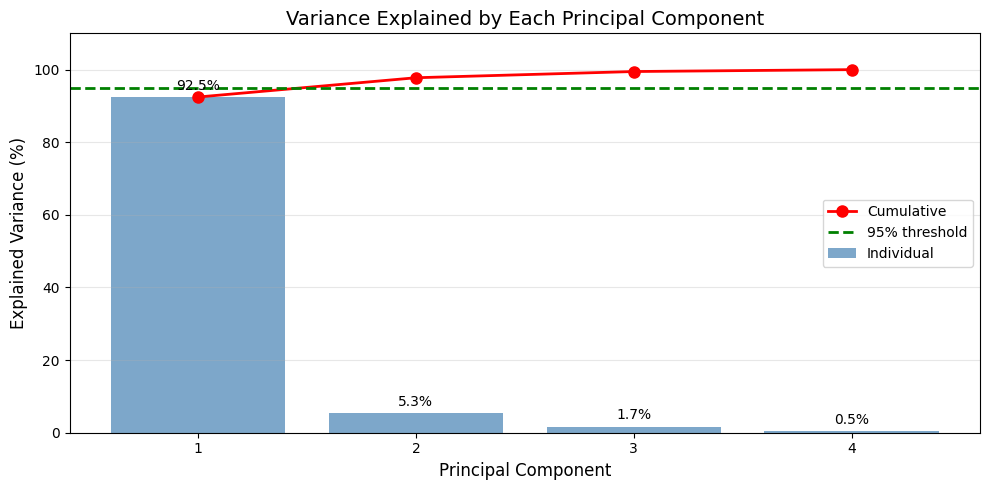


✓ PC1 + PC2 capture 97.8% of variance - we can use just 2D!


In [ ]:
# Visualize explained variance
fig, ax = plt.subplots(figsize=(10, 5))

# Bar chart for individual variance
bars = ax.bar(range(1, 5), explained_variance_ratio * 100,
              color='steelblue', alpha=0.7, label='Individual')

# Line for cumulative variance
ax.plot(range(1, 5), cumulative_variance * 100, 'ro-',
        linewidth=2, markersize=8, label='Cumulative')

# 95% threshold line
ax.axhline(y=95, color='green', linestyle='--', linewidth=2,
           label='95% threshold')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, explained_variance_ratio)):
    ax.text(bar.get_x() + bar.get_width()/2, val*100 + 2,
            f'{val*100:.1f}%', ha='center', fontsize=10)

ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance (%)', fontsize=12)
ax.set_title('Variance Explained by Each Principal Component', fontsize=14)
ax.legend(loc='center right')
ax.set_xticks(range(1, 5))
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ PC1 + PC2 capture 97.8% of variance - we can use just 2D!")

# 6. Projection onto principal components

In [ ]:
X_pca=X_centered@eigenvectors
# verifying: varaince in pcs should match eigenvalues
pca_var=np.var(X_pca,axis=0)
print("PCA_var:")
print(pca_var)
print("\n")
print("eigenvalues:")
print(eigenvalues)
print("\n")
print("They nearly match, so far so good")
print("\n")
# projecting using only 2 components
W_2d=eigenvectors[:,:2]
X_pca_2d=X_centered@W_2d


PCA_var:
[4.20005343 0.24105294 0.0776881  0.02367619]


eigenvalues:
[210.0026714   12.05264715   3.88440517   1.18380962]


They nearly match, so far so good




# 7. PCA visualization


PCA VISUALIZATION


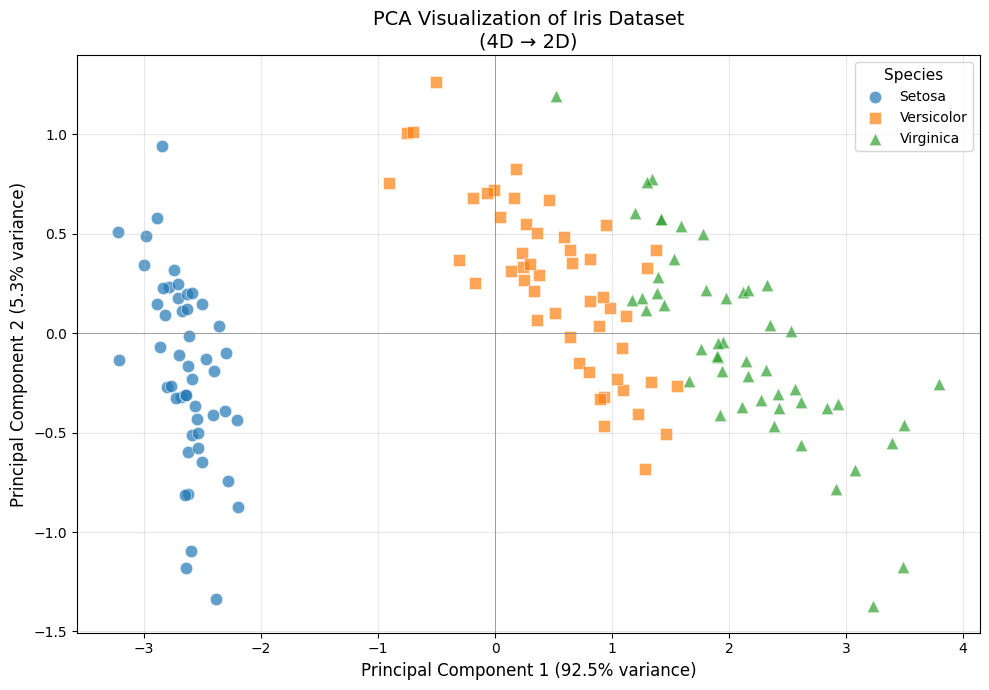


✓ With just 2 components, we capture 97.8% of variance!


In [ ]:
print("=" * 60)
print("PCA VISUALIZATION")
print("=" * 60)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors for each class
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
markers = ['o', 's', '^']  # Circle, Square, Triangle

# Plot each class
for class_idx, (color, marker, name) in enumerate(zip(colors, markers, iris.target_names)):
    # Get indices for this class
    mask = iris.target == class_idx

    # Scatter plot
    ax.scatter(X_pca_2d[mask, 0],    # PC1 values
               X_pca_2d[mask, 1],    # PC2 values
               c=color,
               marker=marker,
               label=name.capitalize(),
               s=80,
               alpha=0.7,
               edgecolors='white',
               linewidth=0.5)

# Labels and title
ax.set_xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Visualization of Iris Dataset\n(4D → 2D)', fontsize=14)

# Legend
ax.legend(title='Species', fontsize=10, title_fontsize=11)

# Grid
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n✓ With just 2 components, we capture {:.1f}% of variance!".format(
    cumulative_variance[1]*100))